## Q1

In [13]:
import numpy as np

# Load the NPZ data from assignment4 folder, assuming the file is named 'data.npz' or similar; adjust filename as needed
data = np.load('./SiesmicEventsClassification_Normalized.npz')
data

NpzFile './SiesmicEventsClassification_Normalized.npz' with keys: data, label

In [14]:
from sklearn.model_selection import train_test_split

# Extract data and labels from the NPZ file
X = data['data']
y = data['label']

# Split into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
X_train.shape,y_train.shape

((800, 6000), (800,))

### U-Net (1D) architecture search (reconstruction)

This dataset is 1D traces with shape `(N, 6000)`, so the U-Net is implemented with `Conv1d` blocks.

Run the grid search below to find the U-Net variant with the lowest reconstruction MSE on the test set. The script logs all trials to `unet_search_results.jsonl` and saves the best checkpoint to `best_unet1d.pt`.


In [17]:
# Runs ~24 trials; on a GPU this typically finishes in minutes.
!python unet_search.py --no-full-retrain --epochs 20 --patience 3 --batch 64

Best UNet1DConfig: UNet1DConfig(in_channels=1, out_channels=1, depth=3, base_channels=32, channel_mult=2, kernel_size=3, norm='none', dropout=0.0, residual=True)
Best val MSE:  0.00020057
Best test MSE: 0.00018410
Saved: best_unet1d.pt
Trials log: unet_search_results.jsonl


In [18]:
import torch
from unet1d import UNet1DConfig

ckpt = torch.load('best_unet1d.pt', map_location='cpu')
best_cfg = UNet1DConfig(**ckpt['cfg'])
print('Best config:', best_cfg)
print('Best val MSE:', ckpt['best_val_mse'])
print('Best test MSE:', ckpt['best_test_mse'])

Best config: UNet1DConfig(in_channels=1, out_channels=1, depth=3, base_channels=32, channel_mult=2, kernel_size=3, norm='none', dropout=0.0, residual=True)
Best val MSE: 0.00020056962331136067
Best test MSE: 0.00018410404761632284


C:\Users\wkkong\AppData\Local\Temp\ipykernel_10800\3327365406.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('best_unet1d.pt', map_location='cpu')


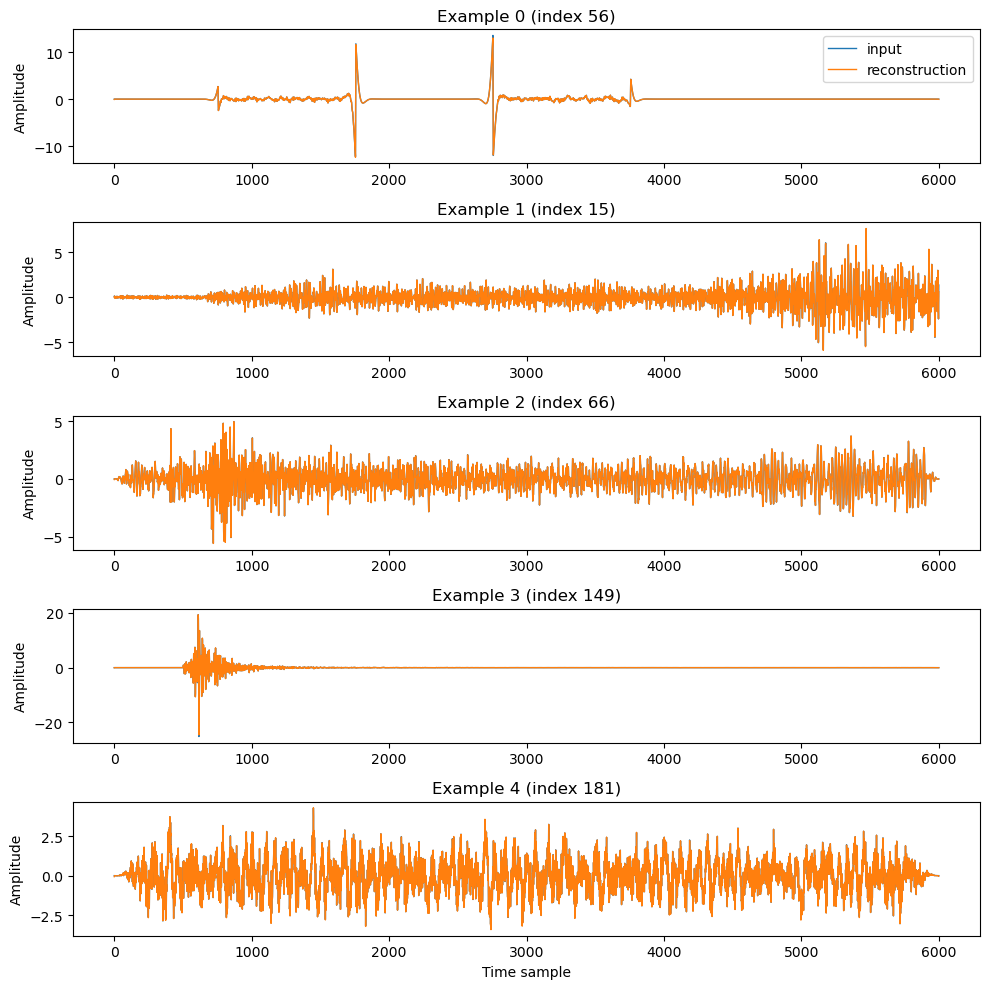

In [19]:
import matplotlib.pyplot as plt
from unet1d import UNet1D

# Build model from the best configuration and checkpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet1D(best_cfg).to(device)
model.load_state_dict(ckpt["state_dict"])
model.eval()

# Select a few example traces from the test set
num_examples = 5
idx = np.random.choice(len(X_test), size=num_examples, replace=False)

with torch.no_grad():
    x = torch.from_numpy(X_test[idx]).float().unsqueeze(1).to(device)  # (B, 1, L)
    pred = model(x).cpu().squeeze(1).numpy()  # (B, L)

plt.figure(figsize=(10, 2 * num_examples))
for i, k in enumerate(idx):
    plt.subplot(num_examples, 1, i + 1)
    plt.plot(X_test[k], label="input", linewidth=1)
    plt.plot(pred[i], label="reconstruction", linewidth=1)
    plt.title(f"Example {i} (index {k})")
    if i == 0:
        plt.legend(loc="upper right")
    plt.ylabel("Amplitude")

plt.xlabel("Time sample")
plt.tight_layout()
plt.show()

### K-means clustering

In this section we use the bottleneck latent representation from the trained 1D U-Net to perform unsupervised clustering (K-means), optionally with PCA for dimensionality reduction.

In [20]:
import numpy as np

from latent_clustering import (
    load_best_unet,
    extract_bottleneck_features,
    run_pca_kmeans,
    pca_2d_for_visualization,
)

# Load the trained best UNet model and its config
model, best_cfg, ckpt = load_best_unet("best_unet1d.pt")
print("Best config:", best_cfg)
print("Best val MSE:", ckpt["best_val_mse"])
print("Best test MSE:", ckpt["best_test_mse"])

Best config: UNet1DConfig(in_channels=1, out_channels=1, depth=3, base_channels=32, channel_mult=2, kernel_size=3, norm='none', dropout=0.0, residual=True)
Best val MSE: 0.00020056962331136067
Best test MSE: 0.00018410404761632284


d:\KAUST\semster2\ML_IN_GEO\assignment4\latent_clustering.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt: dict[str, Any] = torch.load(ckpt_path, map_location=devi

In [21]:
# Extract bottleneck latent features for the test set traces
# X_test has shape (N_test, L)
X_test_latent = extract_bottleneck_features(model, X_test, batch_size=128)
print("Latent feature shape:", X_test_latent.shape)

# Run PCA (to 10D by default) + K-means clustering into 2 clusters
clu_result = run_pca_kmeans(
    X_test_latent,
    n_components_pca=10,
    n_clusters=2,
)

print("PCA latent shape:", clu_result.latent_pca.shape)
print("Cluster labels shape:", clu_result.cluster_labels.shape)

Latent feature shape: (200, 192000)
PCA latent shape: (200, 10)
Cluster labels shape: (200,)


d:\anaconda3\envs\torch_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


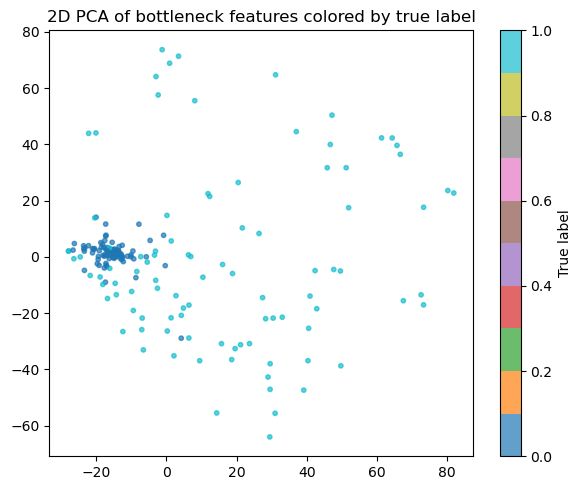

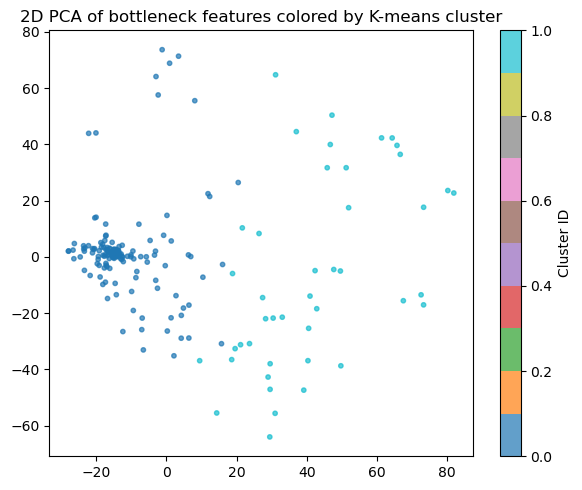

Adjusted Rand Index (ARI) between true labels and clusters: 0.20877270232840855
Confusion matrix (true label vs cluster):
[[102   0]
 [ 54  44]]


In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, confusion_matrix

# 2D PCA coordinates for visualization (separate from the 10D used for clustering)
coords_2d, pca_2d = pca_2d_for_visualization(X_test_latent)

# Scatter plot colored by true labels (if y_test is available)
plt.figure(figsize=(6, 5))
scatter = plt.scatter(coords_2d[:, 0], coords_2d[:, 1], c=y_test, cmap="tab10", s=10, alpha=0.7)
plt.title("2D PCA of bottleneck features colored by true label")
plt.colorbar(scatter, label="True label")
plt.tight_layout()
plt.show()

# Scatter plot colored by K-means cluster assignments
plt.figure(figsize=(6, 5))
scatter = plt.scatter(coords_2d[:, 0], coords_2d[:, 1], c=clu_result.cluster_labels, cmap="tab10", s=10, alpha=0.7)
plt.title("2D PCA of bottleneck features colored by K-means cluster")
plt.colorbar(scatter, label="Cluster ID")
plt.tight_layout()
plt.show()

# Optional: quantitative agreement between clusters and true labels
ari = adjusted_rand_score(y_test, clu_result.cluster_labels)
print("Adjusted Rand Index (ARI) between true labels and clusters:", ari)

print("Confusion matrix (true label vs cluster):")
print(confusion_matrix(y_test, clu_result.cluster_labels))